# **Instalasi Library Tambahan**

In [ ]:
!pip install folium

In [ ]:
!pip install contextily

# **Import Library Utama**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

In [ ]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Memanggil data set lewat google drive
path = "/content/gdrive/MyDrive/MachineLearning/Praktikum11"

# **Loading Dataset**

In [ ]:
df = pd.read_csv(path + '/Data/covid_19_indonesia_time_series_all.csv')
df.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         31822 non-null  object 
 1   Location ISO Code            31822 non-null  object 
 2   Location                     31822 non-null  object 
 3   New Cases                    31822 non-null  int64  
 4   New Deaths                   31822 non-null  int64  
 5   New Recovered                31822 non-null  int64  
 6   New Active Cases             31822 non-null  int64  
 7   Total Cases                  31822 non-null  int64  
 8   Total Deaths                 31822 non-null  int64  
 9   Total Recovered              31822 non-null  int64  
 10  Total Active Cases           31822 non-null  int64  
 11  Location Level               31822 non-null  object 
 12  City or Regency              0 non-null      float64
 13  Province        

In [ ]:
df.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Date,0
Location ISO Code,0
Location,0
New Cases,0
New Deaths,0
New Recovered,0
New Active Cases,0
Total Cases,0
Total Deaths,0
Total Recovered,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.fillna(0)

# **Exploratory Data Analysis (EDA)**

# **5.1 Visualisasi Heatmap LOkasi Covid**

In [ ]:
# Membuat peta dasar indonesia
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=5)

# Membuat list data [latitude, longitude, total cases] untuk heatmap
heat_data = df[['Latitude','Longitude','Total Cases']].values

# Menambahkan heatmap ke peta
HeatMap(heat_data, radius=15).add_to(m)

# Menampilkan peta
m

# **5.2 Peta Sebaran Kasus Dengan Basemap**

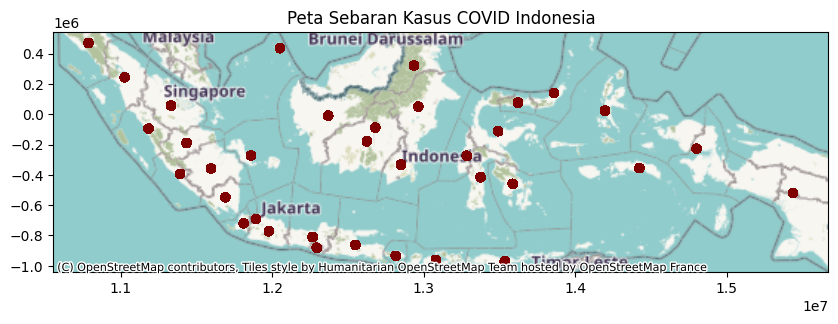

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

gdf= gdf.to_crs(3857)

ax= gdf.plot(figsize=(10,10), alpha=0.6, c=df['Total Cases'], cmap='OrRd')
ctx.add_basemap(ax)
plt.title("Peta Sebaran Kasus COVID Indonesia")
plt.show()

# **5.3 Visualisai Peta dan Grafik Bar**

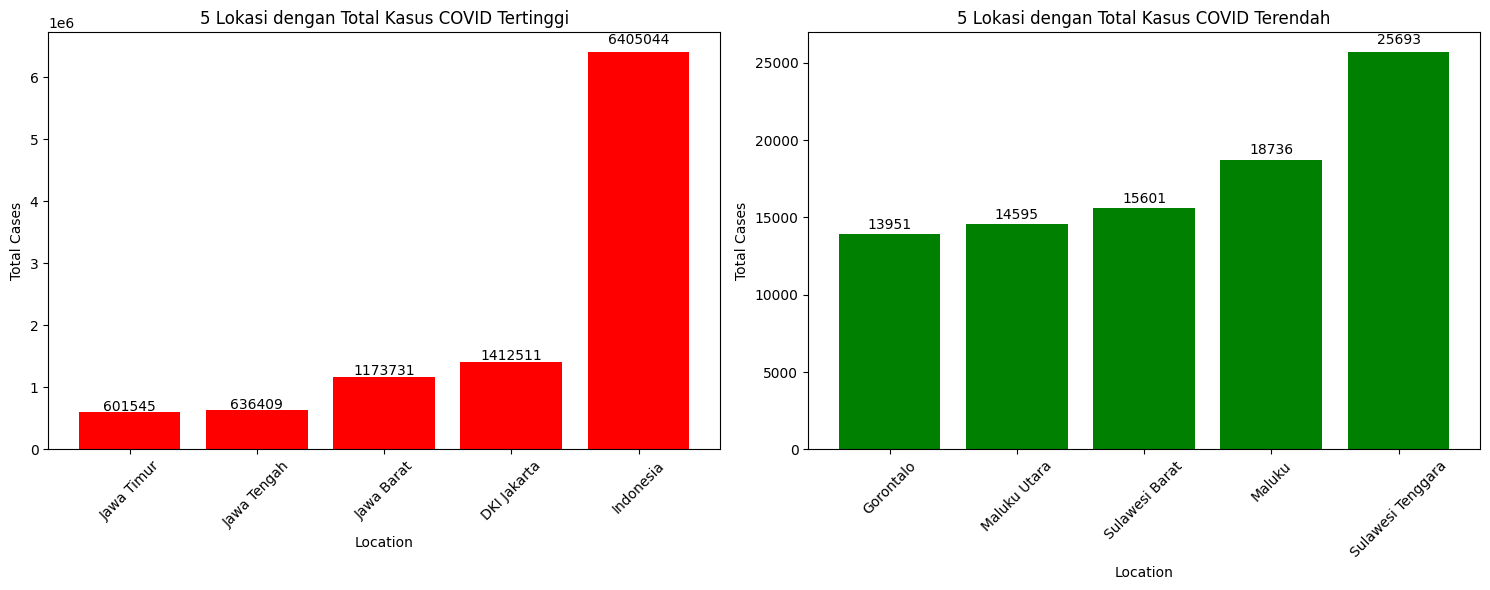

In [ ]:
# Menghitung Top 5 dan Bottom 5 Berdasarkan Total Cases COVID
cases = df.groupby("Location")["Total Cases"].max().sort_values()

top_5 = cases.tail(5)
bottom_5 = cases.head(5)

# Membuat Figure Dengan 2 grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1 - Top 5 (Merah)
axes[0].bar(top_5.index, top_5.values, color='red')
axes[0].set_title("5 Lokasi dengan Total Kasus COVID Tertinggi")
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Total Cases")
axes[0].tick_params(axis='x', rotation=45)

# Menambahkan Nilai di Atas Bar
for i, v in enumerate(top_5.values):
    axes[0].text(i, v + (v*0.02), f"{v}", ha='center')

# Grafik 2 - Bottom 5 (Hijau)
axes[1].bar(bottom_5.index, bottom_5.values, color='green')
axes[1].set_title("5 Lokasi dengan Total Kasus COVID Terendah")
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Total Cases")
axes[1].tick_params(axis='x', rotation=45)

# Menambahkan Nilai di Atas Bar
for i, v in enumerate(bottom_5.values):
    axes[1].text(i, v + (v*0.02), f"{v}", ha='center')

# Menampilkan Grafik
plt.tight_layout()
plt.show()

# **5.4 Visualisasi Rata - Rata SALAR**Y

In [ ]:
df.columns

Index(['Date', 'Location ISO Code', 'Location', 'New Cases', 'New Deaths',
       'New Recovered', 'New Active Cases', 'Total Cases', 'Total Deaths',
       'Total Recovered', 'Total Active Cases', 'Location Level',
       'City or Regency', 'Province', 'Country', 'Continent', 'Island',
       'Time Zone', 'Special Status', 'Total Regencies', 'Total Cities',
       'Total Districts', 'Total Urban Villages', 'Total Rural Villages',
       'Area (km2)', 'Population', 'Population Density', 'Longitude',
       'Latitude', 'New Cases per Million', 'Total Cases per Million',
       'New Deaths per Million', 'Total Deaths per Million',
       'Total Deaths per 100rb', 'Case Fatality Rate', 'Case Recovered Rate',
       'Growth Factor of New Cases', 'Growth Factor of New Deaths'],
      dtype='object')

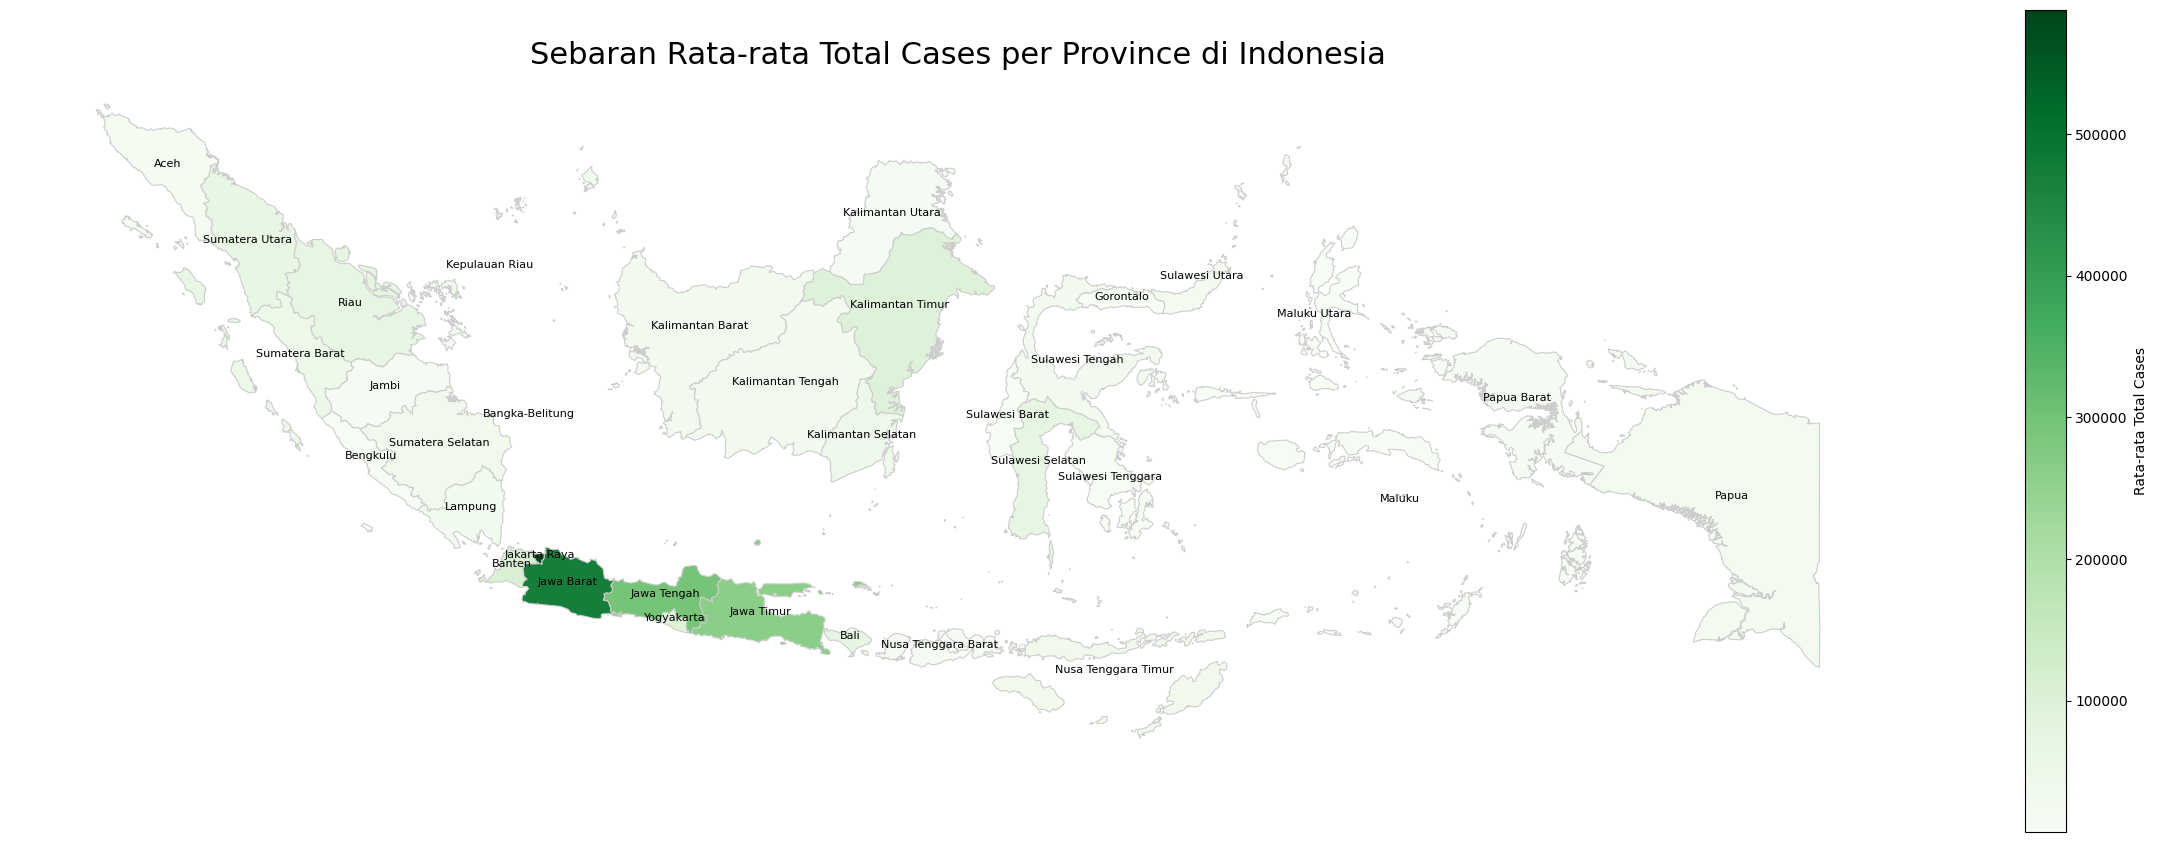

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load GEOJSON
gdf_geo = gpd.read_file(path + '/Data/indonesia.geojson')

# Rename Kolom State Menjadi Province
gdf_geo = gdf_geo.rename(columns={"state": "Province"})

# Menghapus Nama Province Agar Sama Dengan GEOJSON
mapping = {
    "DKI Jakarta": "Jakarta Raya",
    "Daerah Istimewa Yogyakarta": "Yogyakarta"
}
df["Province"] = df["Province"].replace(mapping)

# Menghitung Rata - Rata Total Cases Per Province
rata_total_cases = df.groupby("Province")["Total Cases"].mean().reset_index()

# Merge GEOJSON + Data
gdf_merged = gdf_geo.merge(rata_total_cases, on="Province", how="left")

# Visualisasi MAP
fig, ax = plt.subplots(figsize=(24, 14))

gdf_merged.plot(
    column="Total Cases",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Rata-rata Total Cases",
        "orientation": "vertical",
        "shrink": 0.6,
        "aspect": 20
     }
)

# Menambahkan Label Nama Province Pada Centroid
for idx, row in gdf_merged.iterrows():
    centroid = row.geometry.centroid
    plt.annotate(
        text=row["Province"],
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=8,
        color="black"
    )

ax.set_title("Sebaran Rata-rata Total Cases per Province di Indonesia", fontsize=22)
ax.axis("off")
plt.tight_layout()
plt.show()

# **Uji Normalitas**

In [ ]:
from scipy.stats import shapiro

normalityTest_df = df.select_dtypes(include=['float64','int64'])

normalityTest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   New Cases                    31822 non-null  int64  
 1   New Deaths                   31822 non-null  int64  
 2   New Recovered                31822 non-null  int64  
 3   New Active Cases             31822 non-null  int64  
 4   Total Cases                  31822 non-null  int64  
 5   Total Deaths                 31822 non-null  int64  
 6   Total Recovered              31822 non-null  int64  
 7   Total Active Cases           31822 non-null  int64  
 8   City or Regency              31822 non-null  float64
 9   Total Regencies              31822 non-null  int64  
 10  Total Cities                 31822 non-null  float64
 11  Total Districts              31822 non-null  int64  
 12  Total Urban Villages         31822 non-null  float64
 13  Total Rural Vill

In [ ]:
stat, p = shapiro(normalityTest_df)

print("Statistik: ", stat)
print("P-value: ", p)

if p > 0.05:
  print("Data berdistribusi normal (tidak tolak H0)")
else:
  print("Data tidak berdistribusi normal (tolak H0)")

Statistik:  0.03500258331185713
P-value:  1.0107050756518425e-234
Data tidak berdistribusi normal (tolak H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 859194.
  res = hypotest_fun_out(*samples, **kwds)


# **Analisis Matriks Korelasi (Spearman Correlation)**

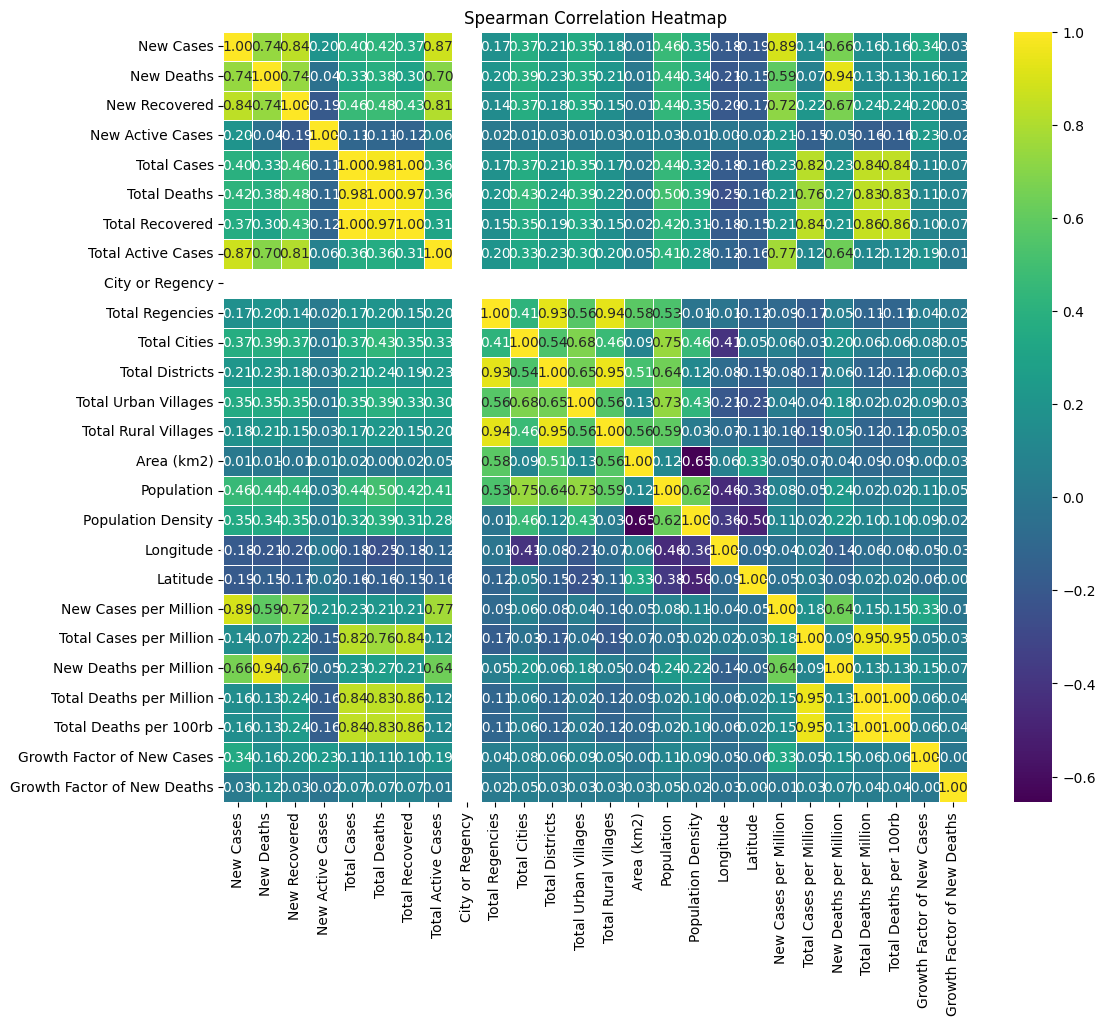

In [ ]:
correlation_df = normalityTest_df

correlation_matrix = correlation_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

# **Analisis Korelasi Spesifik: Total Cases vs Total Deaths**

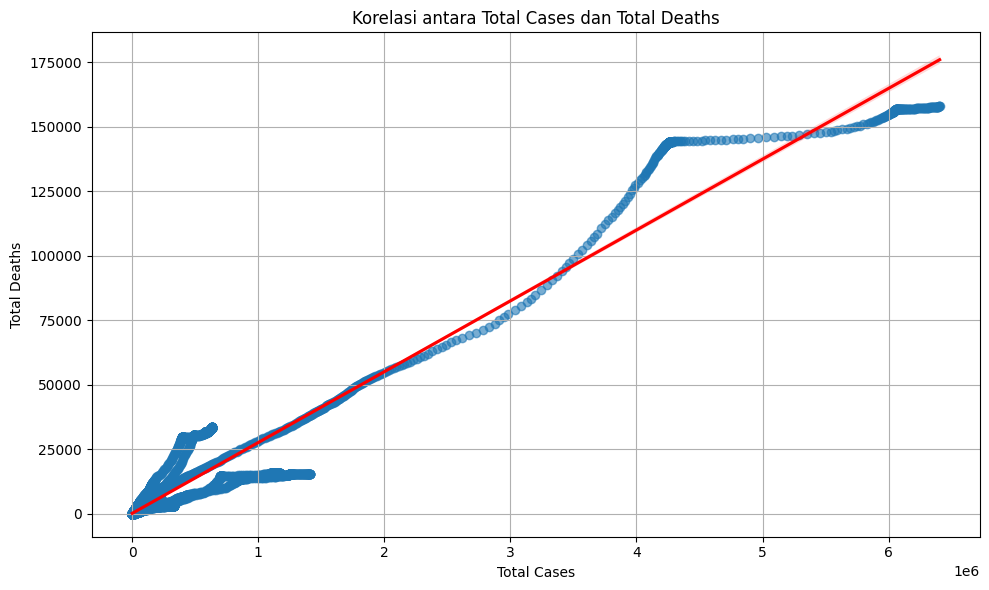

In [ ]:
# Visualisasi Hubungan Antara Indeks
plt.figure(figsize=(10, 6))
sns.regplot(
    x="Total Cases",
    y="Total Deaths",
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={"color": "red"}
)

plt.title("Korelasi antara Total Cases dan Total Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Normalitas Data**

# **9.1 Pemilihan Kolom Untuk Normalisasi**

In [ ]:
normalisasi_df = df.select_dtypes(include=['float64','int64'])

normalisasi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31822 entries, 0 to 31821
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   New Cases                    31822 non-null  int64  
 1   New Deaths                   31822 non-null  int64  
 2   New Recovered                31822 non-null  int64  
 3   New Active Cases             31822 non-null  int64  
 4   Total Cases                  31822 non-null  int64  
 5   Total Deaths                 31822 non-null  int64  
 6   Total Recovered              31822 non-null  int64  
 7   Total Active Cases           31822 non-null  int64  
 8   City or Regency              31822 non-null  float64
 9   Total Regencies              31822 non-null  int64  
 10  Total Cities                 31822 non-null  float64
 11  Total Districts              31822 non-null  int64  
 12  Total Urban Villages         31822 non-null  float64
 13  Total Rural Vill

# **9.2 Proses Normalisasi Dengan RobutScaler**

In [ ]:
from sklearn.preprocessing import RobustScaler

column_names = normalisasi_df.columns
scaler = RobustScaler()
normalisasi_df = scaler.fit_transform(normalisasi_df)
normalisasi_df = pd.DataFrame(normalisasi_df, columns=column_names)
normalisasi_df.head()

,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,City or Regency,Total Regencies,...,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Growth Factor of New Cases,Growth Factor of New Deaths
0,-0.196850,0.0,-0.165289,0.064516,-0.364078,-0.264677,-0.347883,-0.278763,0.0,-0.909091,...,75.522172,-0.436092,-0.583311,-0.257689,-0.512640,0.0,-0.446022,-0.446154,-1.371429,-1.5625
1,-0.196850,0.0,-0.165289,0.064516,-0.364047,-0.264677,-0.347883,-0.277854,0.0,-0.909091,...,75.522172,-0.436092,-0.583311,-0.257689,-0.512627,0.0,-0.446022,-0.446154,0.057143,0.0000
2,-0.196850,0.0,-0.165289,0.064516,-0.364650,-0.274381,-0.349129,-0.252387,0.0,36.818182,...,0.160532,0.033373,0.260642,-0.265610,-0.512911,0.0,-0.451264,-0.451282,-1.371429,-1.5625
3,-0.204724,0.0,-0.165289,0.032258,-0.364666,-0.274381,-0.349112,-0.253297,0.0,-0.090909,...,-0.158392,-0.769446,0.463381,-0.258621,-0.512900,0.0,-0.451264,-0.451282,-1.371429,-1.5625
4,-0.196850,0.0,-0.165289,0.064516,-0.364016,-0.264677,-0.347883,-0.276944,0.0,-0.909091,...,75.522172,-0.436092,-0.583311,-0.257689,-0.512613,0.0,-0.446022,-0.446154,0.057143,0.0000


# **Menentukan Parameter ε (epsilon) Menggunakan K-Distance Graph**

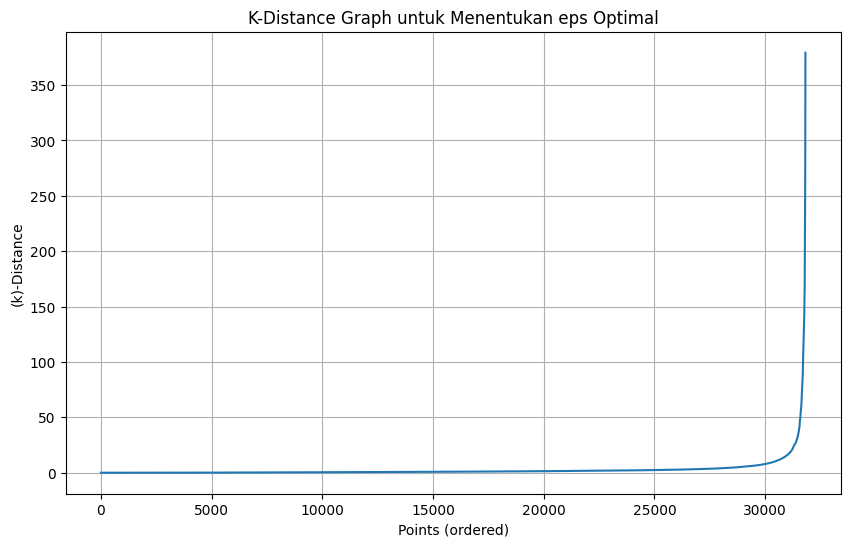

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Gunakan data hasil normalisasi
X = normalisasi_df.values

# Tentukan jumlah tetangga (min_samples biasanya = 4-10)
k = 5

# Fit nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors (X)

# Ambil jarak tetangga ke-k (k-distance)
k_distances = np.sort(distances[:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"(k)-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

# **Clustering Dengan DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3.0, min_samples=5)
labels = dbscan.fit_predict(normalisasi_df.values)

df["Cluster_DBSCAN"] = labels
print(df["Cluster_DBSCAN"].value_counts())

Cluster_DBSCAN
 2     22189
-1      4536
 5       848
 4       780
 3       703
 27      632
 33      574
 34      308
 42      156
 0       148
 28      125
 35      116
 15      109
 46       82
 45       61
 1        58
 36       56
 9        51
 47       32
 13       30
 18       18
 44       15
 7        10
 32        9
 51        9
 23        9
 37        8
 22        8
 17        8
 39        8
 11        7
 24        7
 29        7
 25        7
 8         6
 12        6
 16        6
 6         6
 41        6
 19        5
 14        5
 43        5
 26        5
 20        5
 30        5
 49        5
 21        5
 38        5
 40        5
 50        5
 48        5
 10        4
 31        4
Name: count, dtype: int64


# **Evaluasi Kualitas Clustering Menggunakan Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score

mask = labels != -1         # hilangkan noise
score = silhouette_score(normalisasi_df[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: 0.17099946395505616


# **Visualisasi Hasil Clustering Dengan PCA (2D)**

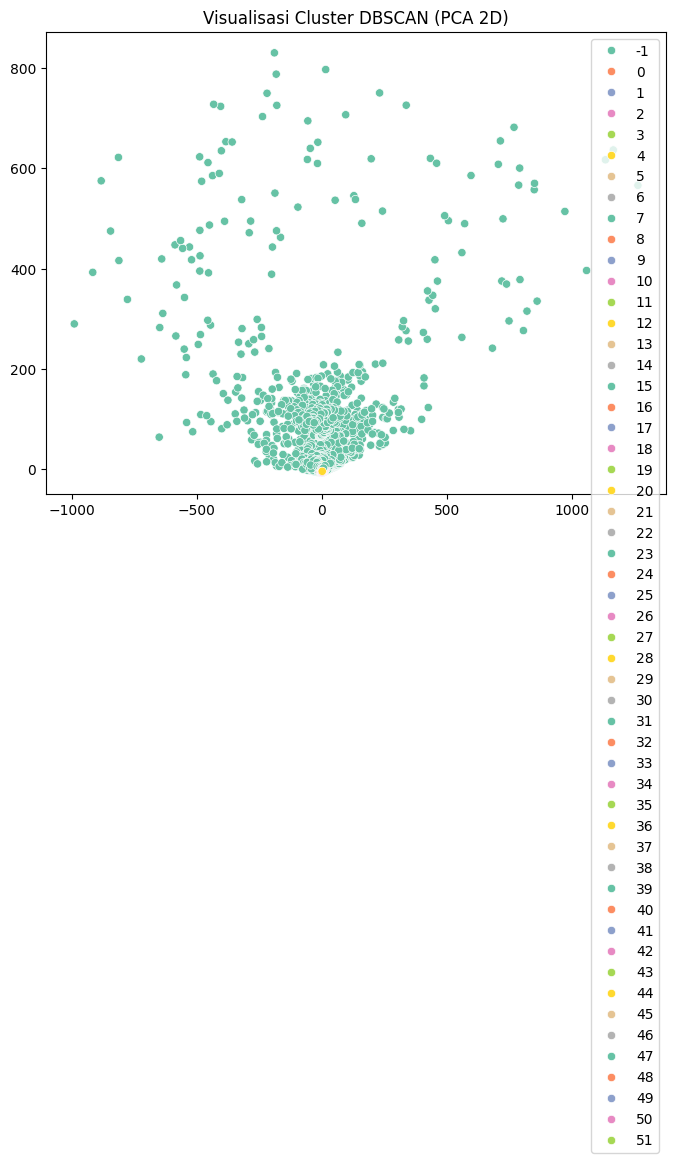

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(normalisasi_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette="Set2")
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.show()

# **Pengelompokan Kualitatif Cluster**

In [ ]:
def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

df['Klasifikasi_DBSCAN'] = df['Cluster_DBSCAN'].apply(klasifikasi_db)
print(df['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Kurang    27138
Noise      4536
Baik        148
Name: count, dtype: int64


# **Analisis Lanjutan per Cluster (Cluster Summary)**

In [ ]:
cluster_summary_db = df.select_dtypes(include=['float64','int64']).groupby('Cluster_DBSCAN').mean()

cluster_summary_db

,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,City or Regency,Total Regencies,...,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Growth Factor of New Cases,Growth Factor of New Deaths
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,
-1,2439.473545,59.261684,2390.267196,-10.055335,6.561235e+05,17685.803351,6.055705e+05,32867.132937,0.0,81.323633,...,2212.909735,111.229723,-3.632377,117.176823,19476.406424,2.771407,439.113787,43.911338,1.849548,1.567974
0,168.378378,4.871622,118.722973,44.783784,8.356365e+03,448.398649,4.470351e+03,3437.614865,0.0,1.000000,...,16334.310000,106.836118,-6.204699,15.523986,770.445946,0.448986,41.341622,4.134054,1.021622,0.705878
1,186.137931,10.086207,39.534483,136.517241,4.117759e+03,323.706897,5.846552e+02,3209.396552,0.0,416.000000,...,138.340000,113.921327,-0.789275,0.702586,15.528103,0.038103,1.220345,0.121897,0.941379,0.766552
2,46.852900,1.105097,43.556222,2.191581,2.662125e+04,743.208437,2.508618e+04,791.861192,0.0,10.474109,...,163.263813,114.167867,-2.100040,13.889452,8329.250302,0.294667,213.217555,21.321759,1.141999,0.811618
3,190.189189,10.100996,151.722617,28.365576,1.579956e+04,1083.072546,1.209515e+04,2621.332859,0.0,25.495021,...,1068.274595,110.281060,-7.317603,4.703713,392.315249,0.253158,27.208378,2.720868,1.165747,0.921508
4,60.115385,1.796154,59.505128,-1.185897,6.285648e+04,1569.197436,5.995719e+04,1330.089744,0.0,25.000000,...,203.820000,99.051964,2.191894,4.041205,4225.677282,0.120692,105.493115,10.549192,1.047782,0.909538
5,41.277123,0.424528,16.852594,24.000000,2.433457e+04,324.681604,1.992771e+04,4082.176887,0.0,28.000000,...,13.600000,138.696030,-4.666210,9.509729,5606.595059,0.097642,74.805000,7.479776,1.097818,0.769387
6,32.666667,0.666667,12.166667,19.833333,4.796833e+03,118.833333,4.435667e+03,242.333333,0.0,8.833333,...,74.521667,122.319049,-2.092981,19.055000,2158.725000,0.395000,52.136667,5.213333,24.666667,0.750000
7,1060.900000,38.600000,551.300000,471.000000,3.805560e+04,2123.700000,1.416110e+04,21770.800000,0.0,416.000000,...,138.340000,113.921327,-0.789275,4.000000,143.506000,0.145000,8.008000,0.801000,1.056000,0.941000


# **Visualisasi Interaktif Persebaran Cluster (Plotly)**

In [ ]:
#Data untuk hover
import plotly.express as px

df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = df["Klasifikasi_DBSCAN"].values
df_pca_db["Location"] = df["City or Regency"].values

#Plotly interaktif
fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="Location",
    title="Persebaran Data Berdasarkan Klasifikasi (DBSCAN)",
    width=1500,
    height=900
)

fig.show()